In [2]:
!pip install torch torchaudio librosa soundfile audioread matplotlib

In [3]:
import torch
import torchaudio
from datasets import load_dataset, Audio
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import re
import matplotlib.pyplot as plt

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DATASET_PATH = r"C:\Users\user\pytorch-speech-recognition\sberdevices_golos_100h_farfield"
MODEL_NAME = "jonatasgrosman/wav2vec2-large-xlsr-53-russian"
NUM_SAMPLES = 20

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^а-яё0-9 ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def wer(ref, hyp):
    r = ref.split()
    h = hyp.split()

    d = [[0] * (len(h) + 1) for _ in range(len(r) + 1)]

    for i in range(len(r) + 1):
        d[i][0] = i
    for j in range(len(h) + 1):
        d[0][j] = j

    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            if r[i - 1] == h[j - 1]:
                cost = 0
            else:
                cost = 1

            d[i][j] = min(
                d[i - 1][j] + 1,      # deletion
                d[i][j - 1] + 1,      # insertion
                d[i - 1][j - 1] + cost  # substitution
            )

    return d[len(r)][len(h)] / max(1, len(r))

In [6]:
print("[1] Loading dataset...")

dataset = load_dataset(
    "parquet",
    data_dir=DATASET_PATH,
    split="train"
)

dataset = dataset.cast_column("audio", Audio())

[1] Loading dataset...


In [7]:
print("[2] Loading model...")

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model = Wav2Vec2ForCTC.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

[2] Loading model...


Loading weights: 100%|██████████| 424/424 [00:00<00:00, 6152.09it/s]


Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projec

In [8]:
print("[3] Running test...")
wer_list = [] 
total_wer = 0

for i in range(NUM_SAMPLES):
    sample = dataset[i]

    # audio
    audio = sample["audio"]
    waveform = torch.tensor(audio["array"]).unsqueeze(0)
    sr = audio["sampling_rate"]

    # resample
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    # mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # model input
    input_values = processor(
        waveform.squeeze(),
        return_tensors="pt",
        sampling_rate=16000
    ).input_values.to(DEVICE)

    # inference
    with torch.no_grad():
        logits = model(input_values).logits

    pred_ids = torch.argmax(logits, dim=-1)
    pred_text = processor.decode(pred_ids[0])

    # clean
    gt = (
        sample.get("text") or
        sample.get("transcription") or
        sample.get("sentence") or
        sample.get("normalized_text")
    )
    pred = clean_text(pred_text)

    sample_wer = wer(gt, pred)
    total_wer += sample_wer
    wer_list.append(sample_wer) 
    
    print(f"\n--- SAMPLE {i} ---")
    print("GT   :", gt)
    print("PRED :", pred)
    print("WER  :", round(sample_wer, 3))

[3] Running test...

--- SAMPLE 0 ---
GT   : джой источники истории турции
PRED : джоуиспесеньтие история турция
WER  : 1.0

--- SAMPLE 1 ---
GT   : сбер когда начался московская паника тысяча девятьсот сорок первого года
PRED : сберь когда начался московская паника тыше девятьсот сорук первого года
WER  : 0.3

--- SAMPLE 2 ---
GT   : сколько денег осталось на сбербанке
PRED : холька денег осталось на сбербанкин
WER  : 0.4

--- SAMPLE 3 ---
GT   : афина выруби освещение
PRED : афейна вырвоби освущенья
WER  : 1.0

--- SAMPLE 4 ---
GT   : сбер какой сегодня день недели
PRED : сбер покой сегодня день неделе
WER  : 0.4

--- SAMPLE 5 ---
GT   : сбер закинь на мобилу три сотки
PRED : в берзакеном обелутя сотки
WER  : 0.833

--- SAMPLE 6 ---
GT   : афина октябрьская революция в честь кого назвали
PRED : афина актябрьский революции в чесь кого назвали
WER  : 0.429

--- SAMPLE 7 ---
GT   : афина пополни баланс моего мобильного пятьсот рублей
PRED : афина по помню балансного мобильного питсот ру

In [9]:
avg_wer = total_wer / NUM_SAMPLES

accuracy = max(0, 1 - avg_wer)
print("\n======================")
print("FINAL WER:", round(avg_wer, 3))
print("======================") 


FINAL WER: 0.646


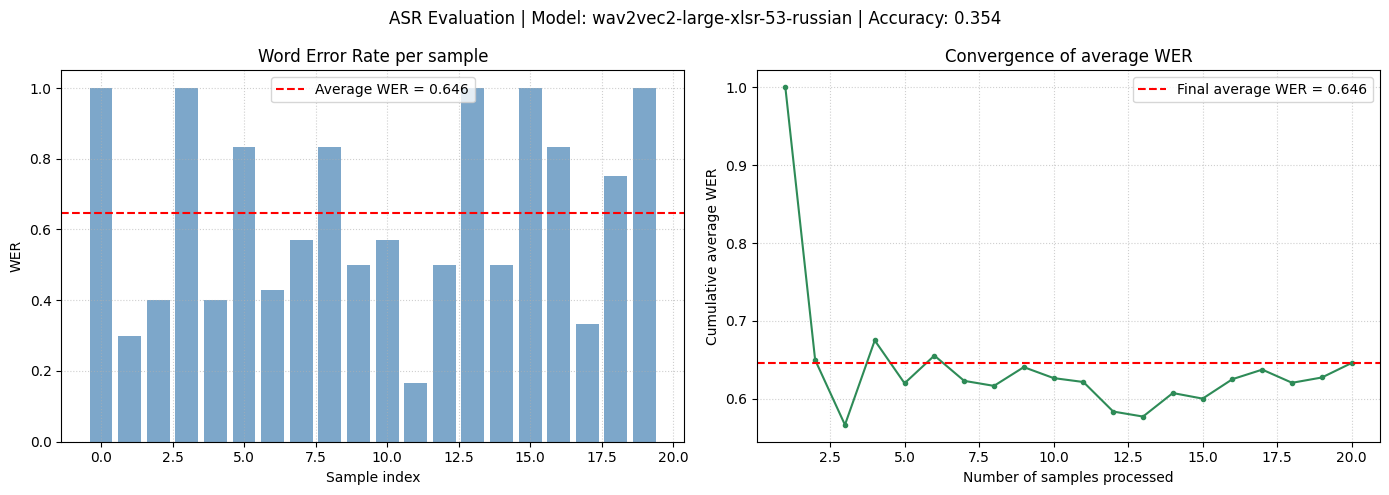

In [12]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(NUM_SAMPLES), wer_list, color='steelblue', alpha=0.7)
plt.axhline(y=avg_wer, color='red', linestyle='--', label=f'Average WER = {avg_wer:.3f}')
plt.xlabel('Sample index')
plt.ylabel('WER')
plt.title('Word Error Rate per sample')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

cumsum = [sum(wer_list[:i+1]) / (i+1) for i in range(NUM_SAMPLES)]
plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_SAMPLES+1), cumsum, marker='.', color='seagreen')
plt.axhline(y=avg_wer, color='red', linestyle='--', label=f'Final average WER = {avg_wer:.3f}')
plt.xlabel('Number of samples processed')
plt.ylabel('Cumulative average WER')
plt.title('Convergence of average WER')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.suptitle(f'ASR Evaluation | Model: {MODEL_NAME.split("/")[-1]} | Accuracy: {accuracy:.3f}')
plt.tight_layout()

plt.savefig('asr_wer_plot.png', dpi=150, bbox_inches='tight')
plt.show()